# Task 5 — Movie Recommendation System

**Objectif :** recommander des films à un utilisateur en fonction de la similarité avec d'autres utilisateurs.

**Dataset :** MovieLens 100K (ml-latest-small) — 100 836 notes, 9742 films, 610 utilisateurs.

In [1]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Chargement des données

In [2]:
# on charge les 2 fichiers utiles pour la reco (les tags et links on n'en a pas besoin ici)
ratings = pd.read_csv("../data/ml-latest-small/ratings.csv")
movies = pd.read_csv("../data/ml-latest-small/movies.csv")

print(ratings.shape, movies.shape)
ratings.head()

(100836, 4) (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
# check rapide, pas de trous
print(ratings.isnull().sum().sum(), movies.isnull().sum().sum())
print("users:", ratings["userId"].nunique(), "| films notés:", ratings["movieId"].nunique())

0 0
users: 610 | films notés: 9724


## 2. Exploration rapide

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_13016\1907027524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="mako", ax=ax)


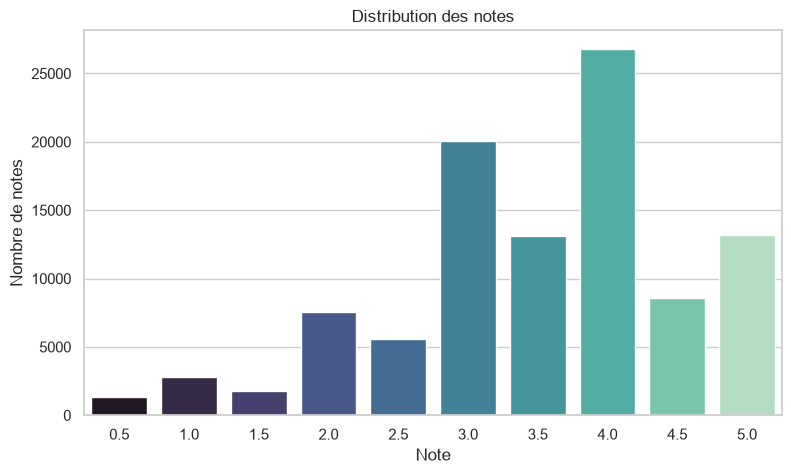

In [4]:
# distribution des notes -> sert à voir si les gens notent plutôt haut ou bas
fig, ax = plt.subplots()
sns.countplot(x="rating", data=ratings, palette="mako", ax=ax)
ax.set_title("Distribution des notes")
ax.set_xlabel("Note")
ax.set_ylabel("Nombre de notes")
plt.savefig("../outputs/01_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

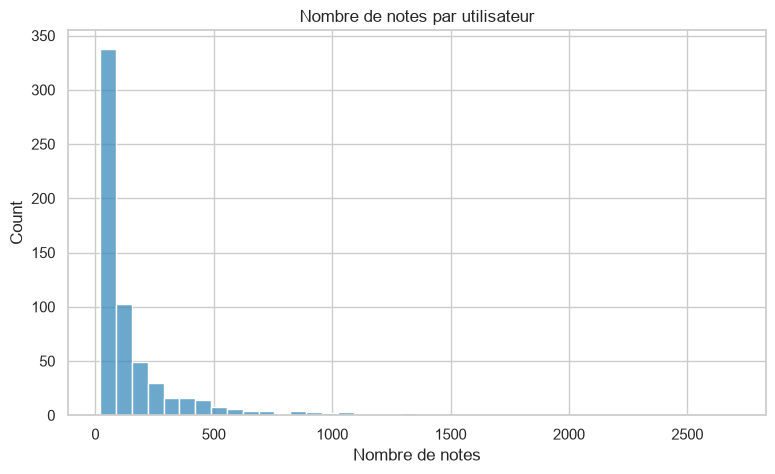

In [5]:
# nombre de notes par utilisateur -> pas mal de gens actifs, quelques très gros contributeurs
notes_par_user = ratings.groupby("userId").size().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.histplot(notes_par_user, bins=40, color="#3b8bba", ax=ax)
ax.set_title("Nombre de notes par utilisateur")
ax.set_xlabel("Nombre de notes")
plt.savefig("../outputs/02_notes_per_user.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Construction de la matrice user-item

In [6]:
# lignes = users, colonnes = films, valeurs = note (NaN si pas noté)
user_item = ratings.pivot_table(index="userId", columns="movieId", values="rating")
print(user_item.shape)
user_item.iloc[:5, :5]

(610, 9724)


movieId,1,2,3,4,5
userId,,,,,
1,4.0,NaN,4.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN


## 4. Similarité entre utilisateurs (cosine similarity)

In [7]:
# on remplace les NaN par 0 juste pour le calcul de similarité (pas pour les prédictions)
user_item_filled = user_item.fillna(0)

user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item.index, columns=user_item.index)

user_similarity_df.iloc[:5, :5].round(2)

userId,1,2,3,4,5
userId,,,,,
1,1.00,0.03,0.06,0.19,0.13
2,0.03,1.00,0.00,0.00,0.02
3,0.06,0.00,1.00,0.00,0.01
4,0.19,0.00,0.00,1.00,0.13
5,0.13,0.02,0.01,0.13,1.00


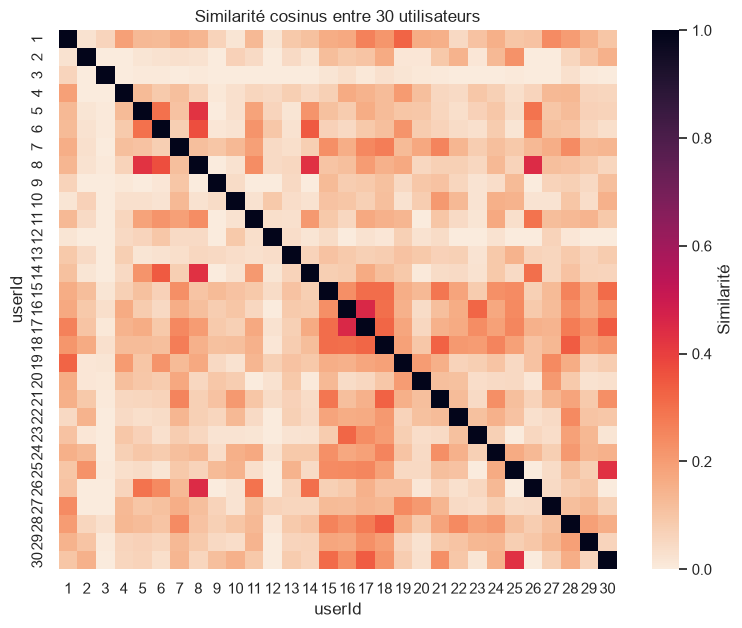

In [8]:
# heatmap sur un échantillon de 30 users pour visualiser les proximités
fig, ax = plt.subplots(figsize=(9, 7))
sample_ids = user_item.index[:30]
sns.heatmap(user_similarity_df.loc[sample_ids, sample_ids], cmap="rocket_r", ax=ax, cbar_kws={"label": "Similarité"})
ax.set_title("Similarité cosinus entre 30 utilisateurs")
plt.savefig("../outputs/03_user_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Fonction de recommandation (basée utilisateur)

In [9]:
def recommend_movies(user_id, n=10):
    # récupère les users les plus proches (hors lui-même)
    sim_scores = user_similarity_df[user_id].drop(user_id).sort_values(ascending=False)
    top_neighbors = sim_scores.head(30).index

    # moyenne pondérée des notes des voisins, pondérée par leur similarité
    # (on prend la version remplie de 0 -> sinon un seul NaN dans le dot product fait planter tout le calcul en NaN)
    neighbor_ratings = user_item_filled.loc[top_neighbors]
    weights = sim_scores.loc[top_neighbors]

    weighted_scores = neighbor_ratings.T.dot(weights) / weights.sum()

    # on enlève les films déjà vus par l'utilisateur
    already_seen = user_item.loc[user_id].dropna().index
    weighted_scores = weighted_scores.drop(already_seen, errors="ignore")

    top_movie_ids = weighted_scores.sort_values(ascending=False).head(n).index
    return movies.set_index("movieId").loc[top_movie_ids][["title", "genres"]]

In [10]:
# test sur un utilisateur au hasard
recommend_movies(user_id=1, n=10)

,title,genres
movieId,,
589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
858,"Godfather, The (1972)",Crime|Drama
2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery
1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
1036,Die Hard (1988),Action|Crime|Thriller
32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
1387,Jaws (1975),Action|Horror
2918,Ferris Bueller's Day Off (1986),Comedy
1968,"Breakfast Club, The (1985)",Comedy|Drama


## 6. Évaluation — Precision@K (avec films cachés)

Si on vérifie juste si les films recommandés (non vus) font partie des films déjà vus et aimés, l'intersection est TOUJOURS vide par construction — les deux ensembles sont mutuellement exclusifs. La bonne méthode : cacher une partie des films aimés avant de recommander, puis vérifier si le modèle les retrouve.

In [11]:
def precision_at_k(user_id, k=10, threshold=4.0, test_fraction=0.3, seed=0):
    # on prend les films que l'utilisateur a vraiment aimés
    user_ratings = ratings[ratings["userId"] == user_id]
    liked = user_ratings[user_ratings["rating"] >= threshold]
    if len(liked) < 2:
        return None

    # on en cache une partie -> le modèle ne doit pas les voir en entraînement
    n_hide = max(1, int(len(liked) * test_fraction))
    hidden = liked.sample(n=n_hide, random_state=seed)
    hidden_movie_ids = set(hidden["movieId"])

    # matrice d'entraînement reconstruite SANS les films cachés
    train_ratings = ratings.drop(hidden.index)
    train_matrix = train_ratings.pivot_table(index="userId", columns="movieId", values="rating")
    train_filled = train_matrix.fillna(0)

    sim = cosine_similarity(train_filled)
    sim_df = pd.DataFrame(sim, index=train_matrix.index, columns=train_matrix.index)

    sim_scores = sim_df[user_id].drop(user_id).sort_values(ascending=False)
    top_neighbors = sim_scores.head(30).index
    neighbor_ratings = train_filled.loc[top_neighbors]
    weights = sim_scores.loc[top_neighbors]
    weighted_scores = neighbor_ratings.T.dot(weights) / weights.sum()

    already_seen = train_matrix.loc[user_id].dropna().index
    weighted_scores = weighted_scores.drop(already_seen, errors="ignore")
    top_movie_ids = set(weighted_scores.sort_values(ascending=False).head(k).index)

    # est-ce qu'on retrouve les films cachés parmi les recommandations ?
    hits = len(top_movie_ids & hidden_movie_ids)
    return hits / k

# échantillon d'utilisateurs (le dataset complet serait trop long à cause du recalcul par user)
sample_users = ratings["userId"].drop_duplicates().sample(30, random_state=42)
scores = [precision_at_k(u, k=10) for u in sample_users]
scores = [s for s in scores if s is not None]

print(f"Precision@10 moyenne sur {len(scores)} users : {np.mean(scores):.3f}")

Precision@10 moyenne sur 30 users : 0.350


→ Cette fois la mesure a du sens : elle dit combien de films *vraiment* cachés (aimés mais retirés avant recommandation) le modèle parvient à retrouver dans son top 10. Un score encore modeste reste normal sur un dataset aussi petit (610 utilisateurs) — le vrai enjeu ici est la méthode d'évaluation, pas la performance brute.

## 7. Filtrage collaboratif item-based

In [12]:
# même logique mais on calcule la similarité entre FILMS plutôt qu'entre users
item_similarity = cosine_similarity(user_item_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item.columns, columns=user_item.columns)

def recommend_movies_item_based(user_id, n=10):
    user_ratings = user_item.loc[user_id].dropna()
    scores = pd.Series(dtype=float)

    for movie_id, rating in user_ratings.items():
        similar = item_similarity_df[movie_id] * rating
        scores = scores.add(similar, fill_value=0)

    scores = scores.drop(user_ratings.index, errors="ignore")
    top_movie_ids = scores.sort_values(ascending=False).head(n).index
    return movies.set_index("movieId").loc[top_movie_ids][["title", "genres"]]

recommend_movies_item_based(user_id=1, n=10)

,title,genres
movieId,,
2918,Ferris Bueller's Day Off (1986),Comedy
1036,Die Hard (1988),Action|Crime|Thriller
1968,"Breakfast Club, The (1985)",Comedy|Drama
1527,"Fifth Element, The (1997)",Action|Adventure|Comedy|Sci-Fi
1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
1391,Mars Attacks! (1996),Action|Comedy|Sci-Fi
2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery
2683,Austin Powers: The Spy Who Shagged Me (1999),Action|Adventure|Comedy
924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi


## 8. Factorisation matricielle (SVD)

In [13]:
from sklearn.decomposition import TruncatedSVD

# SVD sur la matrice remplie de 0 -> réduit à 20 dimensions latentes
svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_item_filled)
reconstructed = np.dot(latent_matrix, svd.components_)
reconstructed_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)

def recommend_movies_svd(user_id, n=10):
    already_seen = user_item.loc[user_id].dropna().index
    predicted_scores = reconstructed_df.loc[user_id].drop(already_seen, errors="ignore")
    top_movie_ids = predicted_scores.sort_values(ascending=False).head(n).index
    return movies.set_index("movieId").loc[top_movie_ids][["title", "genres"]]

recommend_movies_svd(user_id=1, n=10)

,title,genres
movieId,,
589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery
1968,"Breakfast Club, The (1985)",Comedy|Drama
1259,Stand by Me (1986),Adventure|Drama
32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
1036,Die Hard (1988),Action|Crime|Thriller
2918,Ferris Bueller's Day Off (1986),Comedy
858,"Godfather, The (1972)",Crime|Drama


In [14]:
# variance expliquée par les 20 dimensions latentes -> jauge de combien on perd en compressant
print(f"Variance expliquée cumulée (20 composantes) : {svd.explained_variance_ratio_.sum():.1%}")

Variance expliquée cumulée (20 composantes) : 39.2%


**Prochaine étape possible :** comparer précisément le precision@K des 3 approches (user-based, item-based, SVD) sur le même échantillon d'utilisateurs pour voir laquelle généralise le mieux.